In [2]:
%load_ext autoreload
%autoreload 2
from kg.cleaning.referencing.spacy_pipeline_patent import PipelineBuilder, EntityMapper # Adjust import as needed
from PyPDF2 import PdfReader
import os
import amrlib
import penman
from concurrent.futures import ThreadPoolExecutor, as_completed
import torch
from amrlib import load_stog_model
import networkx as nx
import sys, os
from pyvis.network import Network
import os
import json
import xml.etree.ElementTree as ET

import epo_ops
import spacy
from dotenv import load_dotenv
from PatentProvider import PatentProvider
import random
import os
import json
from concurrent.futures import ThreadPoolExecutor, as_completed
import json
from collections import Counter
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import json
import json
import random
import os
import spacy
from spacy.tokens import DocBin
import torch
import matplotlib.pyplot as plt
import amrlib
import spacy
from tools.sentence.sentence import Sentence
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from kg.formatting.formatting_manager import FormattingManager
import sys, importlib,os
sys.modules.pop('PatentTextFormatter', None)
importlib.invalidate_caches()
import numpy as np
from kg.cleaning.normalising.word_normaliser import WordNormaliser
from fastcoref import FCoref
import kg.cleaning.referencing.spacy_pipeline_patent
from tools.sentence.entity import Entity
import torch, os, platform
from kg.generating_kg.generating.NodeGenerator import NodeGenerator
import spacy
import os, pyvis, jinja2, sys
import epo_ops
import epo_ops
import os
import spacy
import xml.etree.ElementTree as ET
import json
import sys
from kg.generating_kg.analysing.TextEncoder import TextEncoder
from PatentProvider import PatentProvider

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import torch

if torch.cuda.is_available():
    torch.cuda.set_per_process_memory_fraction(0.5)  # 50% of VRAM


In [6]:
nlp = spacy.load("en_core_web_trf")   # see optimization ideas below
formatterManager = FormattingManager()
random_description = PatentProvider().getDescription("1502502")
doc = nlp(random_description)
sentences = [sent.text.strip() for sent in doc.sents]  # keep if you need list later
sentence_split = []
def process_sentence(s):
    return formatterManager.split(s)
with ThreadPoolExecutor(max_workers=5) as ex:
    for result in ex.map(process_sentence, sentences):
        sentence_split.extend(result)
print(sentence_split)


obP7iHGVo6HMzenhj3uXdl8T7E7zGPpVGhcRDthgmf6rzZmd


12/25/2025 18:20:50 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:20:50 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:20:50 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:20:50 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:20:50 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:20:52 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:20:52 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:20:53 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:20:53 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "

[parse_string_list] JSON parse exception: Extra data: line 2 column 1 (char 104)
[parse_string_list] RAW: '["The preferred embodiments of the present invention can significantly improve upon existing methods."]\n["The preferred embodiments of the present invention can significantly improve upon existing apparatuses."]'
[parse_string_list] CLEANED: '["The preferred embodiments of the present invention can significantly improve upon existing methods."]\n["The preferred embodiments of the present invention can significantly improve upon existing apparatuses."]'


12/25/2025 18:21:04 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:21:04 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:21:05 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:21:06 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:21:06 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:21:06 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:21:07 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:21:08 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:21:09 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "

[Sentence(text='Field of the Invention.', index=0, source='', span=None, id='930f39ba-5b2e-44ee-8d12-a4aff2431f9d', kg_node_id=None, embedding=None, tokens=[], entities={}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en'), Sentence(text='The present invention relates to a display device for appreciation regarding pseudo space.', index=0, source='', span=None, id='d5379783-f66d-46e0-9922-841a4cd27f2c', kg_node_id=None, embedding=None, tokens=[], entities={}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en'), Sentence(text='The display device is for appreciation regarding pseudo space such as in the water or in the air.', index=1, source='', span=None, id='9bf2a483-6656-4f4d-921a-c6e014ef252e', kg_node_id=None, embedding=None, tokens=[], entities={}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en'), Sentence(text='The display device is for appreciation regarding creatures and/or objects which float in the air.', index=2, source='', 

In [7]:

model_path = "training/info/done/hf/sentence_classifier_model"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

id2label = model.config.id2label

def classify_sentence(text: str):#
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = outputs.logits.softmax(dim=-1)[0]
    pred_id = int(torch.argmax(probs))
    return id2label[pred_id], probs.tolist()

# Example: filter sentences.txtss
for sentence in sentence_split:

    text = sentence.text
    label_name, probs = classify_sentence(text)
    if label_name != "INFORMATIVE":
        sentence_split.remove(sentence)



In [8]:
print(sentence_split)

[Sentence(text='The present invention relates to a display device for appreciation regarding pseudo space.', index=0, source='', span=None, id='d5379783-f66d-46e0-9922-841a4cd27f2c', kg_node_id=None, embedding=None, tokens=[], entities={}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en'), Sentence(text='The display device is for appreciation regarding pseudo space such as in the water or in the air.', index=1, source='', span=None, id='9bf2a483-6656-4f4d-921a-c6e014ef252e', kg_node_id=None, embedding=None, tokens=[], entities={}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en'), Sentence(text='The display device is for appreciation regarding creatures and/or objects which float in the air.', index=2, source='', span=None, id='b2013587-4936-4b23-91e3-7eda48d74adc', kg_node_id=None, embedding=None, tokens=[], entities={}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en'), Sentence(text='Background Art is a section of a patent docume

In [9]:
from typing import Callable

def debug_component_crash(pipeline_builder, sentence_split, sep=" "):
    nlp = pipeline_builder.nlp
    joined_text = sep.join(s.text for s in sentence_split)

    print("Joined chars:", len(joined_text))
    print("Pipeline:", nlp.pipe_names)

    # Build a Doc without running the full pipeline
    doc = nlp.make_doc(joined_text)
    print("make_doc ok. Tokens:", len(doc))

    def run_pipe(pipe_name: str, doc_in):
        pipe = nlp.get_pipe(pipe_name)
        return pipe(doc_in)

    # If you have a HF tokenizer in ner, measure tokens for the joined text
    if "ner" in nlp.pipe_names:
        try:
            ner_pipe = nlp.get_pipe("ner")
            tok = getattr(ner_pipe, "tokenizer", None) or getattr(getattr(ner_pipe, "ner", None), "tokenizer", None)
            if tok is not None:
                ids = tok(joined_text, truncation=False, add_special_tokens=True)["input_ids"]
                print("NER tokenizer tokens:", len(ids))
                print("NER tokenizer model_max_length:", getattr(tok, "model_max_length", None))
        except Exception as e:
            print("Token count probe failed:", repr(e))

    # Run sequentially through the pipeline and stop at the first failing component
    current = doc
    for name in nlp.pipe_names:
        try:
            current = run_pipe(name, current)
            ents = len(getattr(current, "ents", []))
            clusters = getattr(current._, "coref_clusters", None)
            n_clusters = len(clusters) if isinstance(clusters, list) else None
            print(f"✅ {name} ok | ents={ents} | coref_clusters={n_clusters}")
        except Exception as e:
            print(f"\n❌ CRASH in component: {name}")
            print("Error:", repr(e))
            # show a small hint about size
            print("Doc length tokens (spaCy):", len(current))
            print("Joined preview:", repr(joined_text[:300]))
            return name, e

    print("\n✅ No component crashed on joined text")
    return None, None
pipeline_builder = PipelineBuilder()
bad_pipe, err = debug_component_crash(pipeline_builder, sentence_split, sep=" ")
print("Bad pipe:", bad_pipe)


Device set to use cpu
12/25/2025 18:23:39 - INFO - 	 missing_keys: []
12/25/2025 18:23:39 - INFO - 	 unexpected_keys: []
12/25/2025 18:23:39 - INFO - 	 mismatched_keys: []
12/25/2025 18:23:39 - INFO - 	 error_msgs: []
12/25/2025 18:23:39 - INFO - 	 Model Parameters: 590.0M, Transformer: 434.6M, Coref head: 155.4M


Joined chars: 40006
Pipeline: ['sentencizer', 'tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner', 'entity_normaliser', 'windowed_fastcoref', 'local_entity_linker']
make_doc ok. Tokens: 7410
NER tokenizer tokens: 7568
NER tokenizer model_max_length: 1000000000000000019884624838656
✅ sentencizer ok | ents=0 | coref_clusters=0
✅ tok2vec ok | ents=0 | coref_clusters=0
✅ tagger ok | ents=0 | coref_clusters=0
✅ parser ok | ents=0 | coref_clusters=0
✅ attribute_ruler ok | ents=0 | coref_clusters=0
✅ lemmatizer ok | ents=0 | coref_clusters=0


KeyboardInterrupt: 

In [10]:
from dataclasses import dataclass
from typing import List

@dataclass(frozen=True)
class JoinedText:
    """
    Holds the concatenated text passed to spaCy
    and the starting character offset of each sentence.
    """
    text: str
    starts: List[int]


def join_sentences(sentences, sep=" "):
    """
    Join a list of Sentence objects into one string while
    tracking sentence start offsets.

    Args:
        sentences: List of Sentence objects with `.text`
        sep: Separator inserted between sentences (default: space)

    Returns:
        JoinedText(text, starts)
    """
    parts = []
    starts = []
    cur = 0

    for i, s in enumerate(sentences):
        starts.append(cur)
        parts.append(s.text)
        cur += len(s.text)

        if i < len(sentences) - 1:
            parts.append(sep)
            cur += len(sep)

    return JoinedText("".join(parts), starts)


In [11]:
pipeline_builder = PipelineBuilder()
entity_mapper = EntityMapper(sentence_cls=Sentence)

joined = join_sentences(sentence_split, sep=" ")
doc = pipeline_builder.nlp(joined.text)

clusters = entity_mapper.map_to_sentences(doc, sentence_split, joined)

print("doc.ents:", len(doc.ents))
print("coref clusters:", len(doc._.coref_clusters))
print("entities in first sentence:", len(sentence_split[0].entities))


12/25/2025 18:23:50 - INFO - 	 missing_keys: []
12/25/2025 18:23:50 - INFO - 	 unexpected_keys: []
12/25/2025 18:23:50 - INFO - 	 mismatched_keys: []
12/25/2025 18:23:50 - INFO - 	 error_msgs: []
12/25/2025 18:23:50 - INFO - 	 Model Parameters: 590.0M, Transformer: 434.6M, Coref head: 155.4M
12/25/2025 18:24:32 - INFO - 	 Tokenize 1 inputs...
Map: 100%|██████████| 1/1 [00:00<00:00, 22.04 examples/s]
12/25/2025 18:24:33 - INFO - 	 ***** Running Inference on 1 texts *****
Inference: 100%|██████████| 1/1 [00:06<00:00,  6.81s/it]
12/25/2025 18:24:39 - INFO - 	 Tokenize 1 inputs...
Map: 100%|██████████| 1/1 [00:00<00:00, 65.03 examples/s]
12/25/2025 18:24:39 - INFO - 	 ***** Running Inference on 1 texts *****
Inference: 100%|██████████| 1/1 [00:05<00:00,  5.40s/it]
12/25/2025 18:24:45 - INFO - 	 Tokenize 1 inputs...
Map: 100%|██████████| 1/1 [00:00<00:00, 60.39 examples/s]
12/25/2025 18:24:45 - INFO - 	 ***** Running Inference on 1 texts *****
Inference: 100%|██████████| 1/1 [00:05<00:00,  

doc.ents: 1842
coref clusters: 0
entities in first sentence: 5


In [12]:
print(sentence_split)

[Sentence(text='The present invention relates to a display device for appreciation regarding pseudo space.', index=0, source='', span=None, id='d5379783-f66d-46e0-9922-841a4cd27f2c', kg_node_id=None, embedding=None, tokens=[], entities={(0, 21): Entity(The present invention), (35, 42): Entity(display), (43, 49): Entity(device), (54, 66): Entity(appreciation), (77, 89): Entity(pseudo space)}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en'), Sentence(text='The display device is for appreciation regarding pseudo space such as in the water or in the air.', index=1, source='', span=None, id='9bf2a483-6656-4f4d-921a-c6e014ef252e', kg_node_id=None, embedding=None, tokens=[], entities={(4, 18): Entity(display device), (26, 38): Entity(appreciation), (49, 55): Entity(pseudo), (56, 61): Entity(space), (77, 82): Entity(water), (93, 96): Entity(air)}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en'), Sentence(text='The display device is for appreciation regar

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import json
import threading
from typing import Any

triples = []

def sentence_entities_to_llm_inventory(sentence_obj) -> list[dict]:
    inv = []
    for (start, end), ent in sorted(sentence_obj.entities.items(), key=lambda kv: kv[0][0]):
        inv.append({
            "id": ent.ref,              # stable kb id
            "label": ent.label,
            "span": [start, end],
            "text": ent.name,
            "ref_short": getattr(ent, "ref_short", None),
        })
    return inv


# --- Thread-safe NodeGenerator creation (recommended) ---
_thread_local = threading.local()

def get_node_gen():
    if not hasattr(_thread_local, "node_gen"):
        _thread_local.node_gen = NodeGenerator()
    return _thread_local.node_gen



def process_sentence(sent):
    entities = sentence_entities_to_llm_inventory(sent)
    node_gen = get_node_gen()  # thread-local instance

    # IMPORTANT: NodeGenerator.run must accept sentence + entities
    result = node_gen.run(sent.text, entities)

    return result


MAX_WORKERS = 8
for i in sentence_split:
    print(i.text, "->", [e.name for e in i.entities.values()])

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    future_to_idx = {executor.submit(process_sentence, s): idx for idx, s in enumerate(sentence_split)}

    for future in as_completed(future_to_idx):
        idx = future_to_idx[future]
        try:
            result = future.result()
            triples.extend(result)
        except Exception as e:
            print(f"Error on sentence {idx}: {e}")


print(triples)


[autoreload of kg.generating_kg.generating.NodeGeneratorAgent failed: Traceback (most recent call last):
  File "c:\Users\Caleb\Documents\LLM Patent Claim Generator Thesis\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Caleb\Documents\LLM Patent Claim Generator Thesis\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
  File "C:\Users\Caleb\AppData\Local\Programs\Python\Python313\Lib\importlib\__init__.py", line 129, in reload
    _bootstrap._exec(spec, module)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 1026, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "c:\Users\Caleb\Documents\LLM Patent Claim Generator Thesis\kg\generating_kg\gen

The present invention relates to a display device for appreciation regarding pseudo space. -> ['The present invention', 'display', 'device', 'appreciation', 'pseudo space']
The display device is for appreciation regarding pseudo space such as in the water or in the air. -> ['display device', 'appreciation', 'pseudo', 'space', 'water', 'air']
The display device is for appreciation regarding creatures and/or objects which float in the air. -> ['display device', 'appreciation', 'creatures', 'objects', 'float in the air']
Background Art is a section of a patent document. -> ['Background Art', 'patent document']
The Background Art section may discuss prior art. -> ['Background Art', 'section', 'prior art']
The Background Art section may explain the need for the invention. -> ['Background Art', 'invention']
Recently, for a purpose of refreshing feelings of residents and the like indoors, interiors with motifs in the water or in the air are provided. -> ['Recently', 'refreshing feelings of', 

12/25/2025 18:36:36 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:36:36 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:36:36 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:36:36 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:36:36 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:36:36 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:36:36 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:36:36 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


RAW: [{"head":"ent::art::9ea30c","relation":"may explain the need for","tail":"ent::invention::5f95db"}]
CONTENT: [{'head': 'ent::art::9ea30c', 'relation': 'may explain the need for', 'tail': 'ent::invention::5f95db'}]
sentence: The aquariums have seaweeds or tropical fish put in a simple water tank. [{'id': 'ent::aquarium::5ef706', 'label': 'HARDWARE', 'span': [4, 13], 'text': 'aquariums', 'ref_short': 'f706'}, {'id': 'ent::seaweed::e3ef20', 'label': 'BIOMOLECULE', 'span': [19, 27], 'text': 'seaweeds', 'ref_short': 'ef20'}, {'id': 'ent::fish::7e7d4d', 'label': 'BIOMOLECULE', 'span': [31, 44], 'text': 'tropical fish', 'ref_short': '7d4d'}, {'id': 'ent::tank::b7c9cf', 'label': 'COMPONENT', 'span': [54, 71], 'text': 'simple water tank', 'ref_short': 'c9cf'}]
RAW: [{"head":"ent::art::9ea30c","relation":"is a section of","tail":"ent::document::80eb0d"}]
CONTENT: [{'head': 'ent::art::9ea30c', 'relation': 'is a section of', 'tail': 'ent::document::80eb0d'}]
sentence: Aquariums are used as a 

12/25/2025 18:36:38 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:36:39 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


...

RAW: [{"head":"ent::explanation::ace9fb","relation":"was made when using","tail":"ent::fish::7e7d4d"},{"head":"ent::explanation::ace9fb","relation":"was made when using","tail":"ent::model::6a82f5"}]
CONTENT: [{'head': 'ent::explanation::ace9fb', 'relation': 'was made when using', 'tail': 'ent::fish::7e7d4d'}, {'head': 'ent::explanation::ace9fb', 'relation': 'was made when using', 'tail': 'ent::model::6a82f5'}]
sentence: Unnatural behavior such as sudden rising of fish models near the air bubble generating member can be avoided. [{'id': 'ent::behavior::4022af', 'label': 'UNCLASSIFIED_ENTITY', 'span': [0, 18], 'text': 'Unnatural behavior', 'ref_short': '22af'}, {'id': 'ent::rise::3c0436', 'label': 'CONDITION', 'span': [27, 40], 'text': 'sudden rising', 'ref_short': '0436'}, {'id': 'ent::model::6a82f5', 'label': 'COMPONENT', 'span': [44, 55], 'text': 'fish models', 'ref_short': '82f5'}, {'id': 'ent::member::f5da5a', 'label': 'COMPONENT', 'span': [65, 93], 'text': 'air bubble generating m

12/25/2025 18:39:43 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:39:43 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


RAW: [{"head":"ent::model::6a82f5", "relation":"are put in", "tail":"ent::liquid::e5b4e8"}, {"head":"ent::liquid::e5b4e8", "relation":"stored inside of", "tail":"ent::tank::b7c9cf"}, {"head":"ent::model::6a82f5", "relation":"for", "tail":"ent::appreciation::b895d3"}]
CONTENT: [{'head': 'ent::model::6a82f5', 'relation': 'are put in', 'tail': 'ent::liquid::e5b4e8'}, {'head': 'ent::liquid::e5b4e8', 'relation': 'stored inside of', 'tail': 'ent::tank::b7c9cf'}, {'head': 'ent::model::6a82f5', 'relation': 'for', 'tail': 'ent::appreciation::b895d3'}]
sentence: Further, display is also available regarding objects represented by spaceships. [{'id': 'ent::display::f44b3f', 'label': 'COMPONENT', 'span': [9, 16], 'text': 'display', 'ref_short': '4b3f'}, {'id': 'ent::object::ec1380', 'label': 'COMPONENT', 'span': [45, 52], 'text': 'objects', 'ref_short': '1380'}, {'id': 'ent::spaceship::2cd61d', 'label': 'COMPONENT', 'span': [68, 78], 'text': 'spaceships', 'ref_short': 'd61d'}]
RAW: [{"head":"ent::m

12/25/2025 18:39:44 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:39:45 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
12/25/2025 18:39:45 - INFO - 	 HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


RAW: [{"head":"ent::model::6a82f5","relation":"can","tail":"ent::swim::1d36bc"}]
CONTENT: [{'head': 'ent::model::6a82f5', 'relation': 'can', 'tail': 'ent::swim::1d36bc'}]
RAW: [{"head": "ent::model::6a82f5", "relation": "are pseudo models of", "tail": "ent::animal::96f341"}, {"head": "ent::animal::96f341", "relation": "in", "tail": "ent::tank::b7c9cf"}]
CONTENT: [{'head': 'ent::model::6a82f5', 'relation': 'are pseudo models of', 'tail': 'ent::animal::96f341'}, {'head': 'ent::animal::96f341', 'relation': 'in', 'tail': 'ent::tank::b7c9cf'}]
RAW: [{"head":"ent::tank::b7c9cf","relation":"is used for appreciation of","tail":"ent::invention::5f95db"},{"head":"ent::tank::b7c9cf","relation":"when used as","tail":"ent::aquarium::5ef706"},{"head":"ent::display::f44b3f","relation":"can be provided of","tail":"ent::model::6a82f5"}]
CONTENT: [{'head': 'ent::tank::b7c9cf', 'relation': 'is used for appreciation of', 'tail': 'ent::invention::5f95db'}, {'head': 'ent::tank::b7c9cf', 'relation': 'when us

In [19]:
print(type(triples[0]))


<class 'dict'>


In [ ]:
# --- ONE CELL: build + visualize a typed KG from List[Triple] (PyVis)
# Expects triples: List[tools.sentence.triple.Triple]
# Triple.head and Triple.tail are Entity objects (with .id or .ref). Relation is Triple.relation (str).

import re
import networkx as nx
from pyvis.network import Network

from tools.sentence.triple import Triple
from tools.sentence.entity import Entity  # only for type hints

# ---------------- Config: type -> DISTINCT color ----------------
LABELS = [
    "INVENTION","COMPONENT","SUBSYSTEM","MATERIAL","CHEMICAL","BIOMOLECULE","COMPOSITION",
    "PROCESS_STEP","METHOD","PARAMETER","MEASUREMENT","CONDITION","FUNCTION","SIGNAL",
    "CONTROL","SOFTWARE","HARDWARE","FIGURE_REF","CLAIM_ELEMENT","PRIOR_ART",
    "UNCLASSIFIED_ENTITY","unknown",
]

DISTINCT_COLORS = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4",
    "#46f0f0", "#f032e6", "#bcf60c", "#fabebe", "#008080", "#e6beff",
    "#9a6324", "#fffac8", "#800000", "#aaffc3", "#808000", "#ffd8b1",
    "#000075", "#808080", "#a9a9ff",
]

NODE_TYPE_COLORS = {t: DISTINCT_COLORS[i % len(DISTINCT_COLORS)] for i, t in enumerate(LABELS)}
NODE_TYPE_COLORS["unknown"] = "#bdbdbd"

# ---------------- Helpers ----------------

def infer_type_from_id(x: str) -> str:
    """
    Optional heuristic; keep your existing implementation if you already have one.
    Fallback: unknown.
    """
    if not x:
        return "unknown"
    # Example: ENTITYTYPE:12345  -> ENTITYTYPE
    m = re.match(r"^([A-Za-z_]+)[:\-]", str(x))
    return m.group(1).upper() if m else "unknown"

def _entity_key(e: Entity) -> str:
    """
    Returns stable node key for an Entity.
    Adjust depending on your Entity fields:
      - if Entity has .ref use that
      - else if it has .id use that
      - else fall back to str(e)
    """
    if e is None:
        return ""
    if hasattr(e, "ref") and getattr(e, "ref"):
        return str(getattr(e, "ref"))
    if hasattr(e, "id") and getattr(e, "id"):
        return str(getattr(e, "id"))
    return str(e)

def _entity_type(e: Entity) -> str:
    """
    Pull type from Entity if present; else unknown.
    Adjust field names to match your Entity class.
    """
    for attr in ("type", "entity_type", "label", "kind"):
        if hasattr(e, attr) and getattr(e, attr):
            val = str(getattr(e, attr))
            return val.upper()
    return "unknown"

def flatten_triples(triple_groups) -> list[Triple]:
    """
    Accepts:
      - List[Triple]
      - List[List[Triple]] (nested)
      - single Triple
    Returns flat List[Triple].
    """
    if triple_groups is None:
        return []

    if isinstance(triple_groups, Triple):
        return [triple_groups]

    if isinstance(triple_groups, list):
        out: list[Triple] = []
        for item in triple_groups:
            if item is None:
                continue
            if isinstance(item, Triple):
                out.append(item)
            elif isinstance(item, list):
                out.extend([t for t in item if isinstance(t, Triple)])
        return out

    return []

def build_graph(triples, node_type_map=None) -> nx.MultiDiGraph:
    """
    triples: List[Triple] (or nested lists)
    node_type_map: optional dict[str, str] mapping node_id -> type
    """
    node_type_map = node_type_map or {}
    G = nx.MultiDiGraph()
    flat = flatten_triples(triples)

    for tr in flat:
        h_id = _entity_key(tr.head)
        t_id = _entity_key(tr.tail)
        r = (tr.relation or "").strip()

        if not h_id or not t_id or not r:
            continue

        h_type = (node_type_map.get(h_id) or _entity_type(tr.head) or infer_type_from_id(h_id))
        t_type = (node_type_map.get(t_id) or _entity_type(tr.tail) or infer_type_from_id(t_id))

        if not G.has_node(h_id):
            G.add_node(h_id, node_type=h_type)
        if not G.has_node(t_id):
            G.add_node(t_id, node_type=t_type)

        # keep relation as edge label; include triple id if you want traceability
        G.add_edge(h_id, t_id, label=r, triple_id=getattr(tr, "id", None))

    return G

# ---------------- Build ID -> Name map ----------------
# Works with your existing sentence_split data: ent.ref + ent.name
id_to_name = {}
for sent in sentence_split:
    for ent in sent.entities.values():
        ent_id = getattr(ent, "ref", None) or getattr(ent, "id", None)
        if not ent_id:
            continue
        prev = id_to_name.get(ent_id)
        if prev is None or (getattr(ent, "name", "") and len(ent.name) > len(prev)):
            id_to_name[ent_id] = ent.name

# ---------------- PyVis visualization ----------------
def visualize_pyvis(G: nx.MultiDiGraph, out_file="graph.html", id_to_name=None):
    id_to_name = id_to_name or {}
    net = Network(height="100vh", width="100%", directed=True, notebook=False)
    net.barnes_hut()

    for n in G.nodes():
        t = G.nodes[n].get("node_type", "unknown")
        t = t.upper() if t != "unknown" else "unknown"
        color = NODE_TYPE_COLORS.get(t, NODE_TYPE_COLORS["unknown"])
        label = id_to_name.get(n, n)

        net.add_node(
            n,
            label=label,
            color=color,
            shape="ellipse",
            title=f"name: {label}<br>id: {n}<br>type: {t}",
        )

    for u, v, _k, d in G.edges(keys=True, data=True):
        net.add_edge(
            u, v,
            label=d.get("label", ""),
            arrows="to",
            color="#999999",
            width=1.5,
        )

    net.show(out_file, notebook=False)
    print(f"✅ Interactive graph written to {out_file}")

# ---------------- RUN ----------------
# triples should now be: List[Triple]
node_type_map = {}
G = build_graph(triples, node_type_map=node_type_map)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

visualize_pyvis(G, out_file="graph.html", id_to_name=id_to_name)


Nodes: 222
Edges: 737
graph.html
✅ Interactive graph written to graph.html


In [ ]:
# --- ONE CELL: Upload MultiDiGraph to Neo4j Aura WITHOUT losing relation info (one edge per triple) ---

import re
import networkx as nx
from neo4j import GraphDatabase

# ---------------- Helpers ----------------
def sanitize_label(s: str) -> str:
    """Neo4j labels must be identifiers; keep it simple."""
    s = (s or "Entity").strip()
    s = re.sub(r"[^A-Za-z0-9_]", "_", s)
    if re.match(r"^\d", s):
        s = "_" + s
    return s or "Entity"

def sanitize_rel_type(s: str) -> str:
    """Neo4j relationship types must be identifiers."""
    s = (s or "LINKS_TO").upper().strip()
    s = re.sub(r"[^A-Z0-9_]", "_", s)
    if re.match(r"^\d", s):
        s = "_" + s
    return s or "LINKS_TO"

def json_safe(v):
    if v is None:
        return None
    if isinstance(v, (str, int, float, bool, list, dict)):
        return v
    return str(v)

# ---------------- Core uploader ----------------
def push_multidigraph_to_aura(
    G: nx.MultiDiGraph,
    uri: str,
    user: str,
    password: str,
    node_label: str = "Entity",
    rel_type: str = "LINKS_TO",
    id_to_name: dict | None = None,
    batch_nodes: int = 2000,
    batch_edges: int = 5000,
    dedupe_edges: bool = True,
):
    """
    Uploads:
      - Nodes: MERGE by id
      - Edges: creates ONE relationship per original edge (triple),
              storing relation phrase in r.relation

    If dedupe_edges=True, uses MERGE on (a)-[:LINKS_TO {relation, key}]->(b)
    so identical duplicates don't explode.
    """
    node_label = sanitize_label(node_label)
    rel_type = sanitize_rel_type(rel_type)
    id_to_name = id_to_name or {}

    driver = GraphDatabase.driver(uri, auth=(user, password))

    def chunked(lst, n):
        for i in range(0, len(lst), n):
            yield lst[i:i+n]

    # -------- Build node rows --------
    node_rows = []
    for n, attrs in G.nodes(data=True):
        nid = str(n)
        props = {}
        for k, v in (attrs or {}).items():
            props[k] = json_safe(v)
        # friendly name (optional)
        props.setdefault("name", id_to_name.get(nid, nid))
        props.setdefault("id", nid)
        node_rows.append({"id": nid, "props": props})

    # -------- Build edge rows (NO collapsing) --------
    edge_rows = []
    for u, v, k, attrs in G.edges(keys=True, data=True):
        source = str(u)
        target = str(v)
        relation = ""
        if attrs:
            relation = attrs.get("label", "") or attrs.get("relation", "") or ""

        # Make a stable edge key if you want dedupe / traceability
        # (u, v, k, relation) is usually enough
        edge_key = f"{source}||{target}||{k}||{relation}"

        props = {"relation": str(relation), "key": edge_key}
        # keep any other edge attrs too (optional)
        for kk, vv in (attrs or {}).items():
            if kk == "label":
                continue
            props[kk] = json_safe(vv)

        edge_rows.append({"source": source, "target": target, "props": props})

    def tx_nodes(tx, rows):
        tx.run(
            f"""
            UNWIND $rows AS row
            MERGE (n:{node_label} {{id: row.id}})
            SET n += row.props
            """,
            rows=rows,
        )

    def tx_edges(tx, rows):
        if dedupe_edges:
            # Distinct edges by key+relation to avoid duplicates across runs
            tx.run(
                f"""
                UNWIND $rows AS row
                MATCH (a:{node_label} {{id: row.source}})
                MATCH (b:{node_label} {{id: row.target}})
                MERGE (a)-[r:{rel_type} {{key: row.props.key}}]->(b)
                SET r += row.props
                """,
                rows=rows,
            )
        else:
            # Create every edge (can blow up if you rerun)
            tx.run(
                f"""
                UNWIND $rows AS row
                MATCH (a:{node_label} {{id: row.source}})
                MATCH (b:{node_label} {{id: row.target}})
                CREATE (a)-[r:{rel_type}]->(b)
                SET r += row.props
                """,
                rows=rows,
            )

    with driver.session() as session:
        for rows in chunked(node_rows, batch_nodes):
            session.execute_write(tx_nodes, rows)

        for rows in chunked(edge_rows, batch_edges):
            session.execute_write(tx_edges, rows)

    driver.close()
    print(f"✅ Uploaded to Aura: nodes={len(node_rows)} edges={len(edge_rows)} rel=:{rel_type} label=:{node_label} dedupe_edges={dedupe_edges}")


# ------------------- CONFIG (fill in) -------------------
AURA_URI = "neo4j+s://d599a1dc.databases.neo4j.io"
AURA_USER = "neo4j"
AURA_PASS = os.getenv("AURA_PASS", "")

# Assumes you already have:
#   - G : nx.MultiDiGraph (your graph)
#   - id_to_name : dict (optional, for human-readable node names)
try:
    _id_to_name = id_to_name
except NameError:
    _id_to_name = {}

print("Graph:", "nodes", G.number_of_nodes(), "edges", G.number_of_edges())

# Upload: one relationship per triple
push_multidigraph_to_aura(
    G,
    uri=AURA_URI,
    user=AURA_USER,
    password=AURA_PASS,
    node_label="Entity",
    rel_type="LINKS_TO",
    id_to_name=_id_to_name,
    dedupe_edges=True,   # set False if you want every run to create new edges
)


Graph: nodes 215 edges 716
✅ Uploaded to Aura: nodes=215 edges=716 rel=:LINKS_TO label=:Entity dedupe_edges=True


Encoder using device: cuda


In [34]:
import torch
import torch.nn.functional as F    # for F.normalize


# ----------------------------------
# 0) Hyperparameter
# ----------------------------------
SIM_THRESHOLD = 0.75   # tune this


# ----------------------------------
# 1) Cosine similarity helper
# ----------------------------------
def cosine(emb_a: torch.Tensor, emb_b: torch.Tensor) -> float:
    """
    Compute cosine similarity between two 1D embeddings.
    """
    emb_a = emb_a.view(-1)
    emb_b = emb_b.view(-1)

    a_norm = F.normalize(emb_a, dim=0)
    b_norm = F.normalize(emb_b, dim=0)

    return torch.dot(a_norm, b_norm).item()


# ----------------------------------
# 2) Turn an edge into text for embedding
#    (similar style as your original triple embedding)
# ----------------------------------
def edge_to_text(G, u, v, data) -> str:
    """
    Build a textual representation of one triple (edge).
    """
    head_txt = G.nodes[u].get("label", str(u))
    tail_txt = G.nodes[v].get("label", str(v))
    rel_text = data.get("relation", data.get("label", ""))

    # weight head & tail a bit more, like before
    text = (
        f"{head_txt} {head_txt} "
        f"{rel_text} "
        f"{tail_txt} {tail_txt}"
    )
    return text


# ----------------------------------
# 3) Get the FIRST edge from a node, and use it as seed
#    Returns (seed_text, seed_embedding) or (None, None)
# ----------------------------------
def get_first_edge_info(G, node):
    """
    Finds the first incident edge to `node`,
    builds its text, and embeds it with encoder.
    """
    # outgoing / successor edges
    for nbr in G.neighbors(node):
        for key, data in G[node][nbr].items():
            triple_text = edge_to_text(G, node, nbr, data)
            seed_emb = encoder.embed_text_mean(triple_text)
            return triple_text, seed_emb

    # optionally also incoming edges if directed
    if G.is_directed():
        for pred in G.predecessors(node):
            for key, data in G[pred][node].items():
                triple_text = edge_to_text(G, pred, node, data)
                seed_emb = encoder.embed_text_mean(triple_text)
                return triple_text, seed_emb

    return None, None


# ----------------------------------
# 4) Recursive traversal using *path embeddings*
# ----------------------------------
def recursive_traversing(G, node, seed_embedding, sim_threshold, visited, cluster_nodes, path_texts):
    """
    Depth-first traversal starting from `node`.

    We maintain `path_texts`: list of triple-texts along the path so far.
    For each candidate neighbor edge, we:
      - append its triple-text to path_texts
      - embed the whole path with encoder
      - compare the path embedding to the *first-edge* embedding (seed_embedding)
    """
    if node in visited:
        return

    visited.add(node)
    cluster_nodes.add(node)

    # ---------- successors / neighbors ----------
    for nbr in G.neighbors(node):
        # For each edge node -> nbr
        for key, data in G[node][nbr].items():
            triple_text = edge_to_text(G, node, nbr, data)

            # Build text for the extended path: existing + this edge
            new_path_texts = path_texts + [triple_text]
            combined_text = " . ".join(new_path_texts)

            # Embed the whole path
            path_emb = encoder.embed_text_mean(combined_text)

            # Compare to first-edge embedding
            sim = cosine(path_emb, seed_embedding)

            if sim >= sim_threshold and nbr not in visited:
                recursive_traversing(
                    G,
                    nbr,
                    seed_embedding,
                    sim_threshold,
                    visited,
                    cluster_nodes,
                    new_path_texts,
                )

    # ---------- optionally predecessors (for directed graphs) ----------
    if G.is_directed():
        for pred in G.predecessors(node):
            for key, data in G[pred][node].items():
                triple_text = edge_to_text(G, pred, node, data)

                new_path_texts = path_texts + [triple_text]
                combined_text = " . ".join(new_path_texts)

                path_emb = encoder.embed_text_mean(combined_text)
                sim = cosine(path_emb, seed_embedding)

                if sim >= sim_threshold and pred not in visited:
                    recursive_traversing(
                        G,
                        pred,
                        seed_embedding,
                        sim_threshold,
                        visited,
                        cluster_nodes,
                        new_path_texts,
                    )


# ----------------------------------
# 5) Build all clusters
# ----------------------------------
visited = set()
clusters = []          # list[set[node]]
node2cluster = {}      # node -> cluster_id
cluster_id = 0

for node in G.nodes():
    if node in visited:
        continue

    seed_text, seed_emb = get_first_edge_info(G, node)
    if seed_emb is None:
        # node has no incident edges
        continue

    cluster_nodes = set()
    # initial path contains just the seed triple text
    initial_path_texts = [seed_text]

    recursive_traversing(
        G,
        node,
        seed_emb,
        SIM_THRESHOLD,
        visited,
        cluster_nodes,
        initial_path_texts,
    )

    if not cluster_nodes:
        continue

    clusters.append(cluster_nodes)
    for n in cluster_nodes:
        node2cluster[n] = cluster_id

    cluster_id += 1

print("num clusters:", len(clusters))
print("cluster sizes:", [len(c) for c in clusters])


num clusters: 33
cluster sizes: [25, 7, 3, 3, 2, 2, 1, 1, 4, 2, 2, 2, 5, 2, 1, 2, 3, 3, 2, 2, 4, 2, 2, 3, 2, 2, 1, 2, 2, 2, 2, 2, 3]


In [ ]:
import torch

# ----------------------------------
# 1) Define which clusters are "main" (independent-claim candidates)
# ----------------------------------
main_cluster_ids = [0, 1, 2, 3, 4]   # by size / semantics
ATTACH_THRESHOLD = 0.75


# ----------------------------------
# 2) Compute centroids for the main clusters (mean of edge embeddings)
# ----------------------------------
cluster_centroids = {}

for cid in main_cluster_ids:
    embs = []
    for (u, v, key, data) in G.edges(keys=True, data=True):
        if data.get("cluster") == cid:
            emb = data.get("embedding")
            if emb is not None:
                embs.append(emb)

    if embs:
        stacked = torch.stack(embs, dim=0)       # [num_edges_in_cluster, H]
        cluster_centroids[cid] = stacked.mean(dim=0)  # [H]


# ----------------------------------
# 3) Attach non-main edges to the nearest main cluster (by cosine)
# ----------------------------------
edge2parent_claim = {}  # (u, v, key) -> main cluster id or None

for (u, v, key, data) in G.edges(keys=True, data=True):
    edge_cluster = data.get("cluster")

    # Skip edges that already belong to a main cluster
    if edge_cluster in main_cluster_ids:
        continue

    emb = data.get("embedding")
    if emb is None:
        continue

    best_cid = None
    best_sim = -1.0

    for mid, centroid in cluster_centroids.items():
        sim = cosine(emb, centroid)
        if sim > best_sim:
            best_sim = sim
            best_cid = mid

    if best_cid is not None and best_sim >= ATTACH_THRESHOLD:
        edge2parent_claim[(u, v, key)] = best_cid
        # Optionally store on the edge for visualization / export:
        data["parent_claim"] = best_cid
    else:
        edge2parent_claim[(u, v, key)] = None
        data["parent_claim"] = None


# ----------------------------------
# 4) (Optional) Push node cluster ids back into graph nodes
# ----------------------------------
for n, cid in node2cluster.items():
    G.nodes[n]["cluster"] = cid
for u, v, key, d in G.edges(keys=True, data=True):
    d["cluster"] = G.nodes[u].get("cluster", -1)   # or use v, or combine both



In [37]:
from collections import defaultdict

def print_triples_by_cluster(G, cluster_attr="cluster"):
    # cluster_id -> list of triple strings
    clusters = defaultdict(list)

    for head, tail, key, data in G.edges(keys=True, data=True):
        c = data.get(cluster_attr, -1)  # -1 for "no cluster"

        # Get readable node labels (fallback to id)
        head_text = G.nodes[head].get("label", str(head))
        tail_text = G.nodes[tail].get("label", str(tail))

        # Relation text (try "label", then "relation")
        relation_text = data.get("label", data.get("relation", ""))

        triple_str = f"({head_text}, {relation_text}, {tail_text})"
        clusters[c].append(triple_str)

    # Print nicely
    for c in sorted(clusters.keys()):
        if c == -1:
            print("\nUNCLUSTERED EDGES:")
        else:
            print(f"\nCLUSTER {c}:")
        for t in clusters[c]:
            print("  " + t)


# call it after you assigned edge["cluster"]
print_triples_by_cluster(G)



CLUSTER 0:
  (A reservoir for clay, arranged above, the mould containers)
  (the green bricks, produced using, the apparatus)
  (the green bricks, released from, the mould containers)
  (the apparatus, for manufacturing, the green bricks)
  (the apparatus, according to, the invention)
  (the reservoir, for clay into, the mould containers)
  (Figure 1, shows apparatus according to, the invention)
  (Figure 1, shows, the invention)
  (4, on, the conveyor)
  (4, is a perspective view of a first preferred embodiment of a mould container part which is suitable for use in the apparatus according to, the invention)
  (4, is part of, mould container part 4)
  (4, is further provided at both sides with, 32)
  (4, shows a, first)
  (a reservoir 5 for clay, Placed above, the mould containers)
  (reservoir 5, is carried out of into, the mould containers)
  (reservoir 5, is for, 5)
  (13, situated in, mould containers)
  (13, rise in, the mould containers)
  (mould containers, identified as, 21)
 

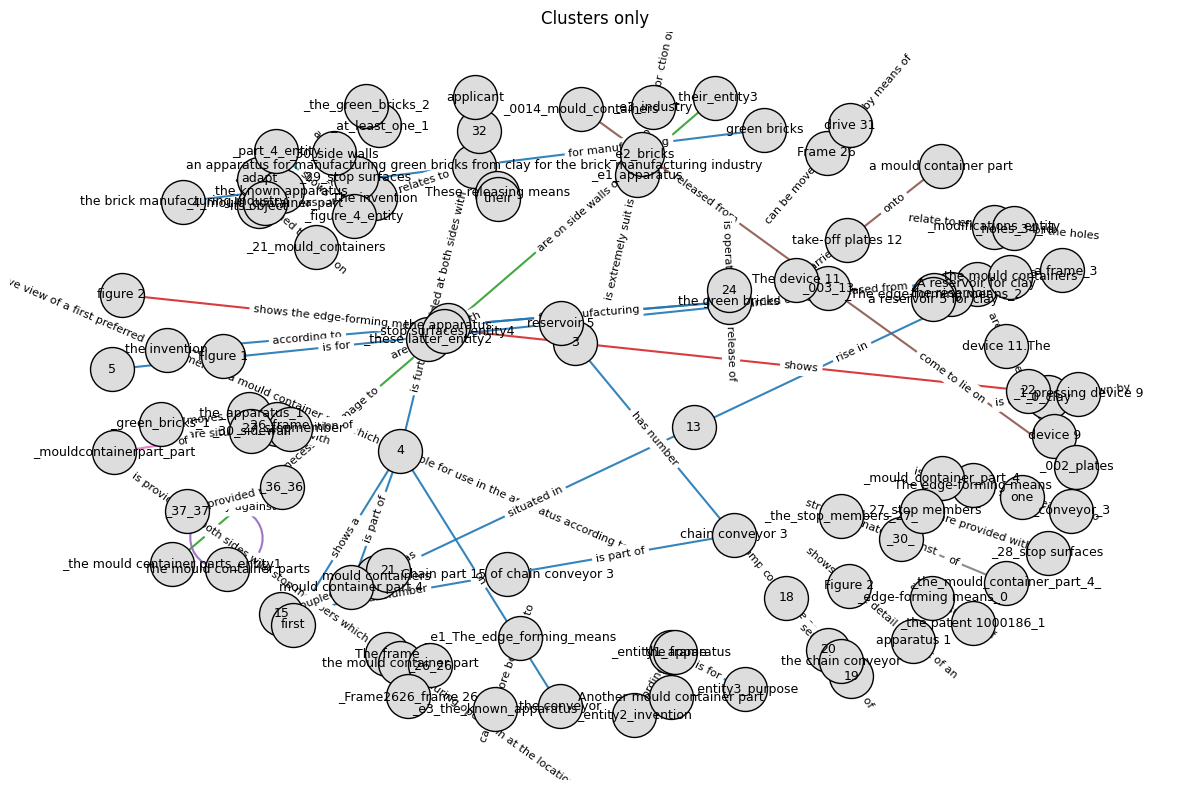

graph_clusters.html
✅ Interactive graph written to graph_clusters.html — open it in your browser.


In [29]:
visualize_matplotlib(G, title="Clusters only")
visualize_pyvis(G, out_file="graph_clusters.html")
